# 🎵 Chinook Database SQL Analysis Project

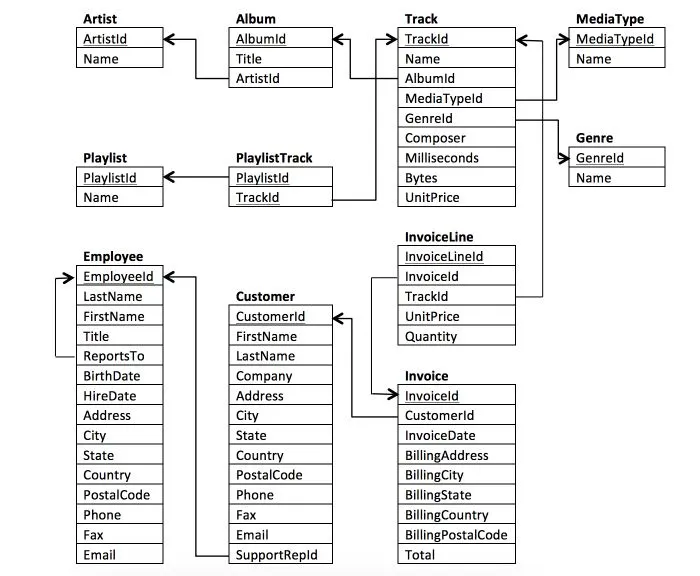
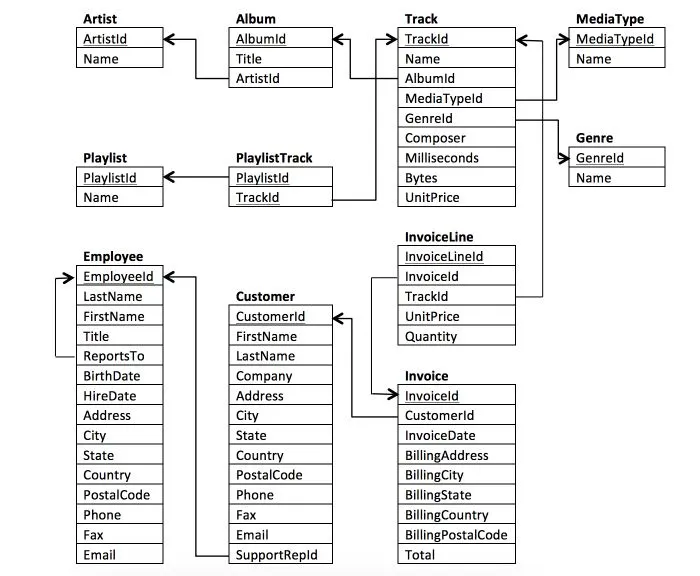

## 📌 Project Overview

This project analyzes the Chinook Music Store Database using SQL and Python to uncover business insights related to customer behavior, sales performance, and revenue trends.

The goal of this project is to:

Analyze customer purchasing behavior
Identify top-selling tracks and artists
Understand revenue distribution
Evaluate employee performance
Discover business growth opportunities

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3 as sql
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Database Connection

In [2]:
conn =sql.connect('/kaggle/input/chinook/Chinook_Sqlite.sqlite')

In [3]:
q="select * from sqlite_master where type= 'table'"

In [4]:
pd.read_sql_query(q,conn)

,type,name,tbl_name,rootpage,sql
0,table,Album,Album,19,CREATE TABLE [Album]\n(\n [AlbumId] INTEGER...
1,table,Artist,Artist,281,CREATE TABLE [Artist]\n(\n [ArtistId] INTEG...
2,table,Customer,Customer,386,CREATE TABLE [Customer]\n(\n [CustomerId] I...
3,table,Employee,Employee,392,CREATE TABLE [Employee]\n(\n [EmployeeId] I...
4,table,Genre,Genre,395,CREATE TABLE [Genre]\n(\n [GenreId] INTEGER...
5,table,Invoice,Invoice,396,CREATE TABLE [Invoice]\n(\n [InvoiceId] INT...
6,table,InvoiceLine,InvoiceLine,399,CREATE TABLE [InvoiceLine]\n(\n [InvoiceLin...
7,table,MediaType,MediaType,402,CREATE TABLE [MediaType]\n(\n [MediaTypeId]...
8,table,Playlist,Playlist,404,CREATE TABLE [Playlist]\n(\n [PlaylistId] I...
9,table,PlaylistTrack,PlaylistTrack,405,CREATE TABLE [PlaylistTrack]\n(\n [Playlist...


## Helper Function for SQL Queries

In [5]:
def sql_query(q):
    return pd.read_sql_query(q,conn)

# 📊 Music Catalog Analysis

## 🎵 Track-wise Album and Artist Details

This query retrieves each track along with its corresponding album title and artist name, providing a complete overview of the music catalog.

In [6]:
q ='''select tr. trackid,alb.title album_title,art.name artist_name
from track tr inner join album alb
      on
      tr.albumid = alb.albumid
      inner join artist art
      on
      alb.artistid =art.artistid'''

In [7]:
sql_query(q)

,TrackId,album_title,artist_name
0,1,For Those About To Rock We Salute You,AC/DC
1,6,For Those About To Rock We Salute You,AC/DC
2,7,For Those About To Rock We Salute You,AC/DC
3,8,For Those About To Rock We Salute You,AC/DC
4,9,For Those About To Rock We Salute You,AC/DC
...,...,...,...
3498,3499,Respighi:Pines of Rome,Eugene Ormandy
3499,3500,Schubert: The Late String Quartets & String Qu...,Emerson String Quartet
3500,3501,Monteverdi: L'Orfeo,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon..."
3501,3502,Mozart: Chamber Music,Nash Ensemble


###  Insight:

This query helps in analyzing how tracks are distributed across albums and artists. It provides a structured view of the music library, making it easier to identify artists with the most tracks and albums available in the store.

## 📊 Number of Tracks Sold by Album and Artist

This query calculates the total number of tracks sold for each album, along with the corresponding artist name, helping evaluate sales performance across artists and albums.

In [8]:
q='''select alb.title album_name,
     art.name artist_name,count(il. trackid) no_of_tracks_sale
     from InvoiceLine il
     inner join track tr
     on
     il. trackid = tr. trackid
     inner join album alb
     on
     tr.albumid = alb.albumid
     inner join artist art
     on
     alb.artistid = art.artistid
     group by 2'''
sql_query(q)

,album_name,artist_name,no_of_tracks_sale
0,For Those About To Rock We Salute You,AC/DC,16
1,The World of Classical Favourites,Academy of St. Martin in the Fields & Sir Nevi...,1
2,"Fauré: Requiem, Ravel: Pavane & Others","Academy of St. Martin in the Fields, John Birc...",1
3,Bach: Orchestral Suites Nos. 1 - 4,"Academy of St. Martin in the Fields, Sir Nevil...",2
4,Balls to the Wall,Accept,5
...,...,...,...
160,Contraband,Velvet Revolver,6
161,Vinicius De Moraes,Vinícius De Moraes,6
162,Bartok: Violin & Viola Concertos,Yehudi Menuhin,1
163,Bach: The Cello Suites,Yo-Yo Ma,1


## Top 5 Track Sold
This query calculates the Top 5 tracks sold for each album,
along with the corresponding track name.

In [9]:
q='''select sum(il.quantity) track_sale,tr.name track_name,alb.title album_name
     from InvoiceLine il
     inner join track tr
     on
     il. trackid =tr. trackid
     inner join album alb
     on
     tr.albumid =alb.albumid
     group by 3
     order by 1 desc
     limit 5'''


In [10]:
df1=sql_query(q)
df1

,track_sale,track_name,album_name
0,27,"Bye, Bye Brasil",Minha Historia
1,26,Are You Gonna Go My Way,Greatest Hits
2,25,Tears In Heaven,Unplugged
3,22,Go Back,Acústico
4,20,Sure Know Something,Greatest Kiss


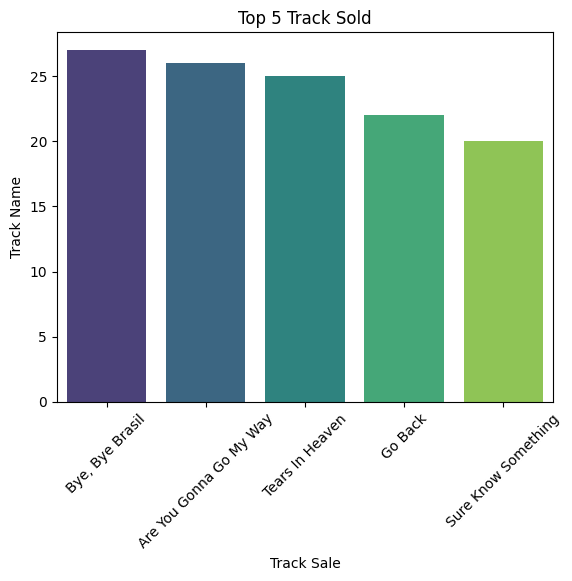

In [11]:
sns.barplot(y=df1['track_sale'],x=df1['track_name'],palette="viridis")
plt.xlabel("Track Sale")
plt.ylabel("Track Name")
plt.title("Top 5 Track Sold")
plt.xticks(rotation=45)
plt.show()

### Insight:
This insight shows that Bye, Bye Brasil is the top track sold.Are You Gonna Go My Way in top 2 position,Tears In Heaven and Go Back along with 3rd and 4th position.Sure Know Something are 5th position these all track are popular beacuse those track sold are little difference.

##  🎼 Number of Tracks in Each Genre

This query calculates the total number of tracks available in each genre, helping identify which genres have the largest music catalog in the database.

In [12]:
q='''select tr.name track_name,gen.genreid genreid,gen.name genre_name,
     count(tr. trackid) no_of_track
     from track tr
     inner join genre gen
     on
     tr.genreid = gen.genreid
     group by genre_name
     order by  no_of_track desc '''
sql_query(q)

,track_name,genreid,genre_name,no_of_track
0,For Those About To Rock (We Salute You),1,Rock,1297
1,Jorge Da Capadócia,7,Latin,579
2,Enter Sandman,3,Metal,374
3,Your Time Has Come,4,Alternative & Punk,332
4,Desafinado,2,Jazz,130
5,Occupation / Precipice,19,TV Shows,93
6,First Time I Met The Blues,6,Blues,81
7,"Symphony No. 3 in E-flat major, Op. 55, ""Eroic...",24,Classical,74
8,Don't Look Back,21,Drama,64
9,Please Please Please,14,R&B/Soul,61


###  Insight:

This analysis reveals which genres dominate the music catalog. Genres with a higher number of tracks indicate a larger content offering, which may influence customer preferences and sales opportunities.

## 💿 Albums with More Than 10 Tracks

This query identifies albums that contain more than 10 tracks, highlighting albums with larger track collections in the music catalog.


In [13]:
q ='''select alb.title album_name, count(tr.trackid) no_of_track from
      track tr
      inner join album alb
      on
      tr.albumid = alb.albumid
      group by album_name
      having count(tr. trackid) > 10

       '''
sql_query(q)

,album_name,no_of_track
0,20th Century Masters - The Millennium Collecti...,12
1,A Matter of Life and Death,11
2,A Real Dead One,12
3,A Real Live One,11
4,A TempestadeTempestade Ou O Livro Dos Dias,15
...,...,...
178,Voodoo Lounge,15
179,Vozes do MPB,14
180,Vs.,12
181,Walking Into Clarksdale,12


# 📊 Employee Analysis

## 👩‍💼 Employee Table Overview

This query retrieves all records and columns from the Employee table, providing a complete overview of employee information in the database.


In [14]:
q='''select * from employee'''

In [15]:
df=sql_query(q)
df.head()

,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2002-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2002-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2002-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com
3,4,Park,Margaret,Sales Support Agent,2.0,1947-09-19 00:00:00,2003-05-03 00:00:00,683 10 Street SW,Calgary,AB,Canada,T2P 5G3,+1 (403) 263-4423,+1 (403) 263-4289,margaret@chinookcorp.com
4,5,Johnson,Steve,Sales Support Agent,2.0,1965-03-03 00:00:00,2003-10-17 00:00:00,7727B 41 Ave,Calgary,AB,Canada,T3B 1Y7,1 (780) 836-9987,1 (780) 836-9543,steve@chinookcorp.com


## Employee Details and Reporting Structure
This query retrieves employee names, job titles, employee IDs,
and their reporting manager IDs.

In [16]:
q='''select firstname||" "||lastname full_name,
     title,employeeid,reportsto from employee'''
sql_query(q)

,full_name,Title,EmployeeId,ReportsTo
0,Andrew Adams,General Manager,1,NaN
1,Nancy Edwards,Sales Manager,2,1.0
2,Jane Peacock,Sales Support Agent,3,2.0
3,Margaret Park,Sales Support Agent,4,2.0
4,Steve Johnson,Sales Support Agent,5,2.0
5,Michael Mitchell,IT Manager,6,1.0
6,Robert King,IT Staff,7,6.0
7,Laura Callahan,IT Staff,8,6.0


## Employee and Supervisor Details Using Self Join
This query joins the employee table with itself to replace the
reportsto ID with the corresponding supervisor's name,
showing the employee–manager relationship.

In [17]:
q='''select emp.firstname||" "||emp.lastname Full_Name,emp.title Employee_Title,
     emp.employeeid ID,emp.reportsto reports,emp2.firstname||" "||emp2.lastname Superviser_Name
     from employee emp
     inner join employee emp2
     on
     emp.reportsto = emp2.employeeid
    '''
sql_query(q)

,Full_Name,Employee_Title,ID,reports,Superviser_Name
0,Nancy Edwards,Sales Manager,2,1,Andrew Adams
1,Jane Peacock,Sales Support Agent,3,2,Nancy Edwards
2,Margaret Park,Sales Support Agent,4,2,Nancy Edwards
3,Steve Johnson,Sales Support Agent,5,2,Nancy Edwards
4,Michael Mitchell,IT Manager,6,1,Andrew Adams
5,Robert King,IT Staff,7,6,Michael Mitchell
6,Laura Callahan,IT Staff,8,6,Michael Mitchell


# 📊 Customer Analysis

## Customer Table Overview
This query retrieves all records and columns from the Customer table.


In [18]:
q='''select * from customer'''
df=sql_query(q)
df.head()

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


## Find customer details which contains 'JEN' in customer name

In [19]:
q='''select firstname||" "||lastname customer_name from customer
     where firstname like "JEN%"
     '''
sql_query(q)

,customer_name
0,Jennifer Peterson


## 🌍 Top-Spending Customer in Each Country

This query identifies the highest-spending customer in each country, helping uncover regional high-value customers and their contribution to total revenue.


In [20]:
q3 ='''WITH customer_spending AS (
    SELECT
        cus.customerid AS Best_customer_id,
        cus.firstname || ' ' || cus.lastname AS Customer_name,
        cus.country AS Country,
        SUM(inv.total) AS Total_spent
    FROM customer cus
    INNER JOIN invoice inv
        ON cus.customerid = inv.customerid
    GROUP BY
        cus.customerid, cus.firstname, cus.lastname, cus.country
),
ranked_customers AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY Country
               ORDER BY Total_spent DESC
           ) AS rn
    FROM customer_spending
)
SELECT
    Best_customer_id,
    Customer_name,
    Country,
    Total_spent AS Top_Buyer
FROM ranked_customers
WHERE rn =1 
order by Top_Buyer desc'''

In [21]:
df3=sql_query(q3)
df3

,Best_customer_id,Customer_name,Country,Top_Buyer
0,6,Helena Holý,Czech Republic,49.62
1,26,Richard Cunningham,USA,47.62
2,57,Luis Rojas,Chile,46.62
3,45,Ladislav Kovács,Hungary,45.62
4,46,Hugh O'Reilly,Ireland,45.62
5,37,Fynn Zimmermann,Germany,43.62
6,7,Astrid Gruber,Austria,42.62
7,44,Terhi Hämäläinen,Finland,41.62
8,43,Isabelle Mercier,France,40.62
9,48,Johannes Van der Berg,Netherlands,40.62


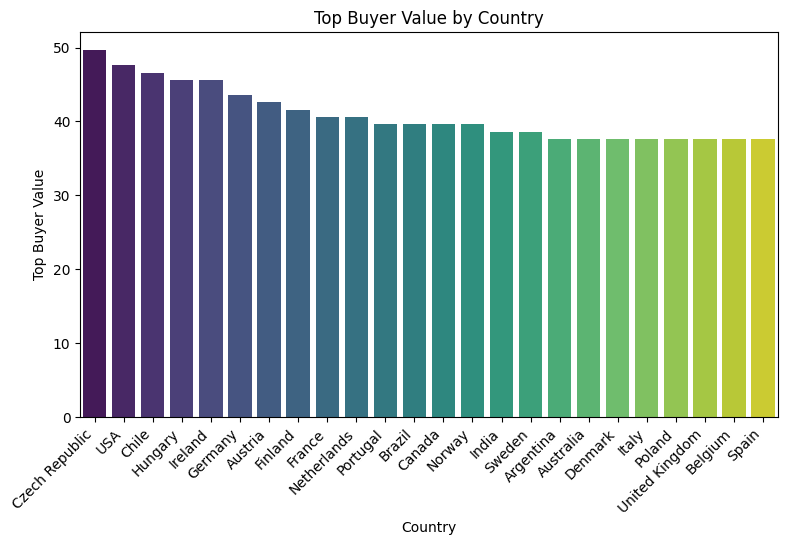

In [22]:
plt.figure(figsize=(9,5))
sns.barplot(x=df3["Country"], y=df3["Top_Buyer"], palette="viridis")
plt.xticks(rotation=45,ha='right')
plt.xlabel("Country")
plt.ylabel("Top Buyer Value")
plt.title("Top Buyer Value by Country")
plt.show()

### Insight:

This analysis highlights the most valuable customer in each country. These customers contribute significantly to regional revenue and can be targeted for loyalty programs, personalized offers, and retention strategies to maximize business growth.

## 🧾Customer-wise Invoice Count and Total Spending

This query calculates the total number of invoices generated by each customer along with their total spending at the store, providing a snapshot of customer purchasing behavior.

In [23]:
q ='''select cus.firstname||" "||cus.lastname customer_name,count(cus.customerid) No_of_invoices,
      sum(inv.total) total from customer cus
      inner join invoice inv
      on
      cus.customerid=inv.customerid
      group by cus.customerid'''
sql_query(q)

,customer_name,No_of_invoices,total
0,Luís Gonçalves,7,39.62
1,Leonie Köhler,7,37.62
2,François Tremblay,7,39.62
3,Bjørn Hansen,7,39.62
4,František Wichterlová,7,40.62
5,Helena Holý,7,49.62
6,Astrid Gruber,7,42.62
7,Daan Peeters,7,37.62
8,Kara Nielsen,7,37.62
9,Eduardo Martins,7,37.62


## Top 5 Customer with No of Invoices and Total Spent
This query calculate the Top Top 5 Customer with No of Invoices and Total Spent

In [24]:
q='''With top_customer as(select
cus.firstname||" "||cus.lastname as Customer_name,
count(inv.invoiceid) as No_of_invoices,
sum(inv.total) as Total_spent,
Rank() Over(order by sum(inv.total) desc) as ranking
from customer cus
inner join invoice inv
on
cus.customerid = inv.customerid
group by cus.customerid 
)
select Customer_name,No_of_invoices, Total_spent
from top_customer
where ranking < 7
'''

In [25]:
df2=sql_query(q)
df2

,Customer_name,No_of_invoices,Total_spent
0,Helena Holý,7,49.62
1,Richard Cunningham,7,47.62
2,Luis Rojas,7,46.62
3,Ladislav Kovács,7,45.62
4,Hugh O'Reilly,7,45.62
5,Julia Barnett,7,43.62


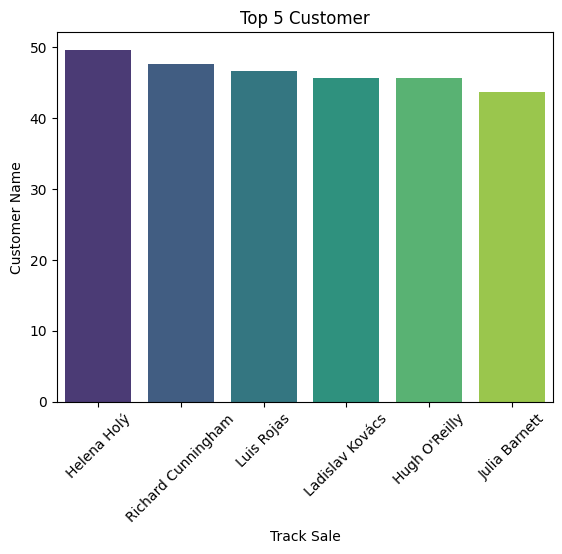

In [26]:
sns.barplot(y=df2['Total_spent'],x=df2['Customer_name'],palette="viridis")
plt.xlabel("Track Sale")
plt.ylabel("Customer Name")
plt.title("Top 5 Customer")
plt.xticks(rotation=45)
plt.show()


### Insight:

This insight shows that Helena Holy is the top customer who spend the most.Richard Cunningham and Luis Rojas 2 and 3 position.4 position sharing Ladislav Kovács and Hugh O'Reilly.Julia Barnett in 5 position	

## Customer Segmentation Based on Total Spending
This query categorizes customers into spending groups
(Small Spender, Regular, Big Spender) based on their total purchase amount.


In [27]:
q='''Select cus.firstname||" "||cus.lastname customer_name,
     count(inv.invoiceid) No_of_invoices,sum(inv.total) Total_Spent,
     Case
         When sum(inv.total) < 40 Then "Small spender"
         When sum(inv.total) > 100  Then "Big Spender"
         Else "Regular"
     End as customer_category
     from invoice inv
     inner join customer cus
     on
     inv.customerid = cus.customerid
     group by cus.customerid '''

In [28]:
sql_query(q)

,customer_name,No_of_invoices,Total_Spent,customer_category
0,Luís Gonçalves,7,39.62,Small spender
1,Leonie Köhler,7,37.62,Small spender
2,François Tremblay,7,39.62,Small spender
3,Bjørn Hansen,7,39.62,Small spender
4,František Wichterlová,7,40.62,Regular
5,Helena Holý,7,49.62,Regular
6,Astrid Gruber,7,42.62,Regular
7,Daan Peeters,7,37.62,Small spender
8,Kara Nielsen,7,37.62,Small spender
9,Eduardo Martins,7,37.62,Small spender


In [29]:
q2='''select cus.firstname||" "||lastname customer_name,count(inv.invoiceid) no_of_invoices,
     sum(inv.total) total_spent,
     Case
         When sum(inv.total) < 40 then "Small spender"
         When sum(inv.total) > 100 then "Big spender"
         Else "Regular"
     End as Customer_category
     from invoice inv
     inner join customer cus
     on
     inv.customerid = cus.customerid
     group by cus.customerid
     '''

In [30]:
df4=sql_query(q2)['Customer_category'].value_counts()
df4

Customer_category
Small spender    45
Regular          14
Name: count, dtype: int64

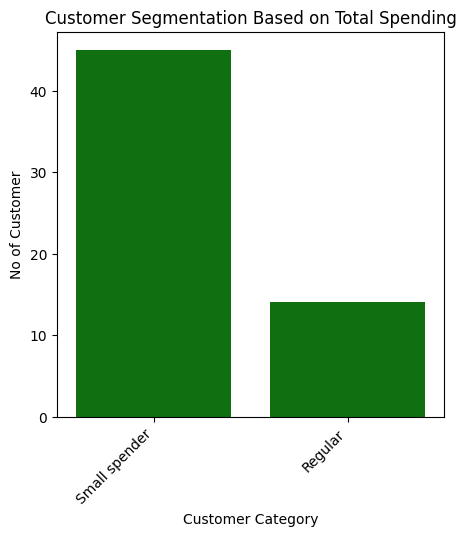

In [31]:
plt.figure(figsize=(5,5))
sns.barplot(df4,color="green")
plt.xticks(rotation=45,ha='right')
plt.xlabel("Customer Category")
plt.ylabel("No of Customer")
plt.title("Customer Segmentation Based on Total Spending")
plt.show()

### Insight:
The majority of customers fall into the Small Spender category with 45 customers, while only 14 customers are classified as Regular. This indicates that most customers contribute smaller purchase amounts, suggesting a wide base of low-value buyers

# **Conclusion:**

This project presents a comprehensive SQL analysis of the Chinook Music Store Database, focusing on customer behavior, sales performance, employee structure, and music catalog insights. Through multiple SQL queries, key business insights were derived to better understand the store’s performance and customer purchasing patterns.

### 🔍 Key Findings

### 🎧 Sales & Music Catalog Insights
Certain albums and artists dominate track sales, indicating strong customer preferences.
Genres with larger track collections provide greater variety and potential for higher engagement.
Albums with more than 10 tracks offer more content value and may attract customers seeking complete collections.

### 👥 Customer Insights
A small number of top customers contribute significantly to total revenue.
Top-spending customers vary by country, highlighting regional purchasing behavior.
Customer segmentation revealed three main groups:
Small Spenders
Regular Customers
High-Value Customers
### 💰 Revenue & Purchasing Behavior
Customers with higher invoice counts generally contribute more revenue.
Track-level invoice analysis helped identify customer-specific preferences.
Some customers make frequent small purchases, while others make fewer high-value purchases.
### 👩‍💼 Employee Insights
The employee table analysis helped understand organizational hierarchy.
Self-join queries identified employee-manager relationships.
These insights can support performance and responsibility tracking.